In [ ]:
import pandas as pd # FOR UPLOADING THE DATA
import numpy as np
import re #  REGULAR EXPRESSION --> USED FOR DATA CLEANING (EG: PUNCTUATION, BULLETPOINTS)
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords # TO REMVOE THE UNNECESSARY WORDS
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import wordcloud # TO VISUALISE THE WORDS

#  DOWNLOAD REQUIRED NLTK FILES
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon') # (VALENCE AWARE DICTIONARY AND SENTIMENT REASONER) RULE BASED SENTIMENT ANALYSIS
nltk.download('punkt_tab') # PUNCTUATION TABS

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

customer review data
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [ ]:
# Sample customer reviews dataset
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display first few rows
print("Customer Reviews Dataset")
print(df.head())

Customer Reviews Dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [ ]:
# Create a set of English stopwords
stop_words = set(stopwords.words('english'))

# Function to clean text
def Clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    print("\nAfter removing special characters:\n", text)

    # Tokenization
    words = word_tokenize(text)
    print("\nTokenized words:\n", words)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    print("\nAfter removing stopwords:\n", words)

    # Join words back into a single string
    cleaned_text = " ".join(words)

    return cleaned_text

# Apply cleaning function to each review
df["Cleaned_Review"] = df["Review"].apply(Clean_text)

# Display cleaned reviews
print("\nCleaned Reviews:\n")
print(df["Cleaned_Review"])


After removing special characters:
 the product quality is excellent and delivery was very fast

Tokenized words:
 ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']

After removing stopwords:
 ['product', 'quality', 'excellent', 'delivery', 'fast']

After removing special characters:
 very bad packaging and the item was damaged

Tokenized words:
 ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']

After removing stopwords:
 ['bad', 'packaging', 'item', 'damaged']

After removing special characters:
 customer service was helpful and responsive

Tokenized words:
 ['customer', 'service', 'was', 'helpful', 'and', 'responsive']

After removing stopwords:
 ['customer', 'service', 'helpful', 'responsive']

After removing special characters:
 the delivery was delayed and support team did not respond

Tokenized words:
 ['the', 'delivery', 'was', 'delayed', 'and', 'support', 'team', 'did', 'not', 'respond']

After removing stopwords:
 [

In [ ]:
# Create Sentiment Analyzer object
sia = SentimentIntensityAnalyzer()

# Function to analyze sentiment
def analyze_sentiment(review):
    score = sia.polarity_scores(review)["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis
df["Sentiment"] = df["Review"].apply(analyze_sentiment)

# Display results
print(df[["Review", "Sentiment"]])

                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


word count


In [ ]:
all_words=" ".join(df['Cleaned_Review'])

word_list=all_words.split()

# COUNT WORD FREQUENCY

word_freq=Counter(word_list)

# DISPLAY TOP 10 KEYWORDS

print("\n Top 10 Common Keywords")
print(word_freq.most_common(10))


 Top 10 Common Keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [ ]:
# Filter negative reviews
negative_reviews = df[df["Sentiment"] == "Negative"]

# Combine all cleaned negative reviews into one string
negative_words = " ".join(negative_reviews["Cleaned_Review"])

# Split into individual words
negative_word_list = negative_words.split()

# Count word frequencies
complaint_freq = Counter(negative_word_list)

# Display top 10 complaint keywords
print("\nMost Common Complaint Keywords:")
print(complaint_freq.most_common(10))


Most Common Complaint Keywords:
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


In [18]:
sentiment_counts = df['Sentiment'].value_counts() #it will give category count
sentiment_counts

,count
Sentiment,
Positive,6
Negative,4


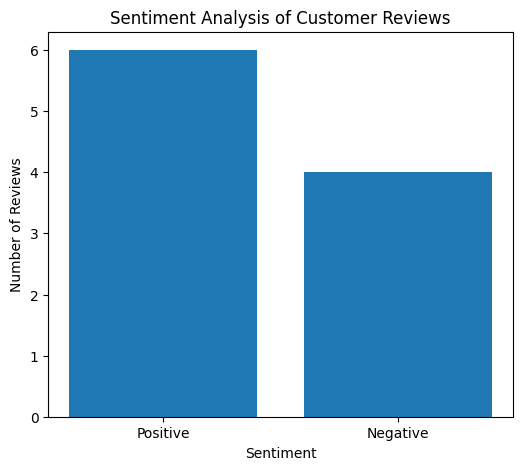

In [19]:
sentiment_counts = df['Sentiment'].value_counts() #it will give category count\


plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentiment Analysis of Customer Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

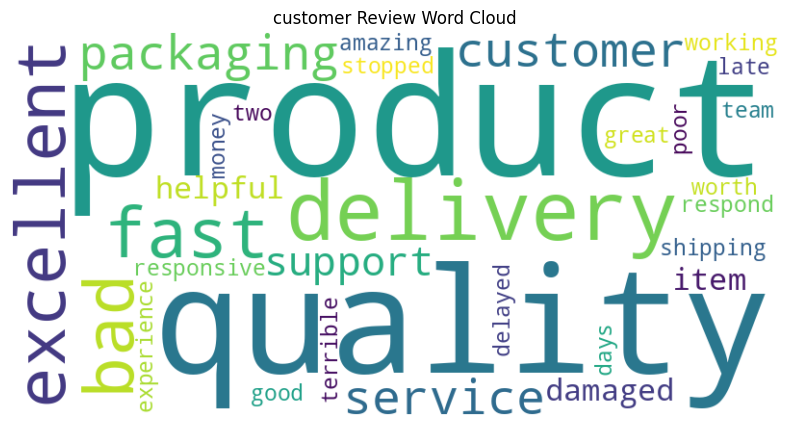

In [21]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("customer Review Word Cloud")
plt.show()

In [23]:
print("\nBuisness Insight")
print("-------------------------")
positive_count = len (df[df['Sentiment'] == 'positive'])
negative_count = len(df[df['Sentiment']=='Negative'])

print("total positive Reviews :", positive_count)
print("total negative reviews :", negative_count)

print("\n common positive Area:")
print("product quality")
print("Fast delivery")
print("good customer service")

print("\n common customer complaints:")
print("- Delayed delivery")
print("-Damaged products")
print("-poor support response")
print("- product malfunction issues")

print("\nReccomendation")
print("the company should improve delivery management")
print("strengthen packing quality and enhance customer support response time")


Buisness Insight
-------------------------
total positive Reviews : 0
total negative reviews : 4

 common positive Area:
product quality
Fast delivery
good customer service

 common customer complaints:
- Delayed delivery
-Damaged products
-poor support response
- product malfunction issues

Reccomendation
the company should improve delivery management
strengthen packing quality and enhance customer support response time
